# Environment Setup

In [1]:
import sys
import os

# Ensure project root is in path
sys.path.append(os.path.abspath(".."))

# Imports

In [2]:
import importlib
import pandas as pd
import matplotlib.pyplot as plt

import model.assumptions as assumptions_module
import model.policy as policy_module
import model.projection as projection_module
import model.valuation as valuation_module
import model.results as results_module
import model.portfolio as portfolio_module
import model.analysis.profit as profit_analysis
import model.data.loader as loader

plt.style.use("seaborn-v0_8")

# Reload Modules

In [3]:
def reload_all():

    importlib.reload(assumptions_module)
    importlib.reload(policy_module)
    importlib.reload(projection_module)
    importlib.reload(results_module)
    importlib.reload(valuation_module)
    importlib.reload(portfolio_module)
    importlib.reload(profit_analysis)

reload_all()

# Notebook Entry Points 
import model.valuation as valuation 
import model.analysis.profit as profit_analysis 
import model.assumptions as assumptions_module 
import model.policy as policy_module

# Assumptions Setup

In [4]:
mortality_parameters = (
    assumptions_module.load_mortality_parameters(
        "../data/mortality_parameters/smoker_multipliers.csv"
    )
)

base_mortality = assumptions_module.load_mortality_table(
    "../data/mortality_tables/ons_mortality.csv"
)

mortality = assumptions_module.MortalityTable(
    mortality_rates=base_mortality.mortality_rates,
    mortality_parameters=mortality_parameters
)

interest = assumptions_module.load_yield_curve(
    "../data/yield_curves/sonia_spot_rates.csv"
)

lapse_table = assumptions_module.load_lapse_table(
    "../data/lapse_rates.csv"
)

assumptions = assumptions_module.AssumptionSet(
    mortality=mortality,
    interest=interest,
    lapse=lapse_table
)

# Portfolio Setup

In [5]:
portfolio = loader.load_portfolio_csv(
    "../data/sample_portfolio.csv"
)

portfolio

=== PORTFOLIO SUMMARY ===
PV Premiums : 1,130,850,075.11
PV Claims   : 1,612,536,790.71
Net Value   : -481,686,715.61

=== EMERGENCE PREVIEW ===


,t,expected_premium,expected_claim,expected_lapse,pv_net,cum_profit
0,0,1.000128e+08,7.382090e+07,818.420000,2.619189e+07,2.619189e+07
1,1,9.759236e+07,7.733236e+07,493.246757,1.944712e+07,4.563901e+07
2,2,9.584207e+07,8.212522e+07,458.481257,1.260431e+07,5.824332e+07
3,3,9.412155e+07,8.709137e+07,425.920349,6.196033e+06,6.443935e+07
4,4,9.242442e+07,9.229512e+07,395.420353,1.092608e+05,6.454861e+07
5,5,8.895990e+07,9.517411e+07,242.579283,-5.032184e+06,5.951643e+07
6,6,8.414229e+07,9.991814e+07,221.836188,-1.221907e+07,4.729736e+07
7,7,8.051427e+07,1.053765e+08,204.258603,-1.838000e+07,2.891736e+07
8,8,7.591221e+07,1.100714e+08,192.887751,-2.407544e+07,4.841920e+06
9,9,7.337841e+07,1.099484e+08,178.686612,-2.454462e+07,-1.970270e+07


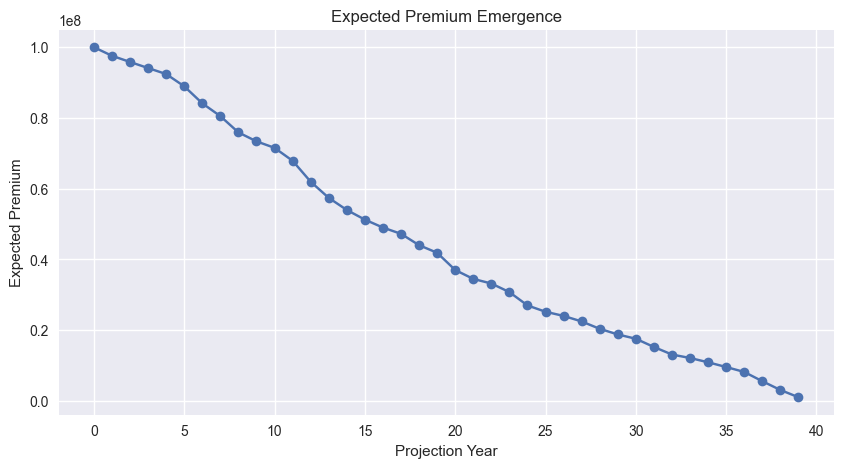

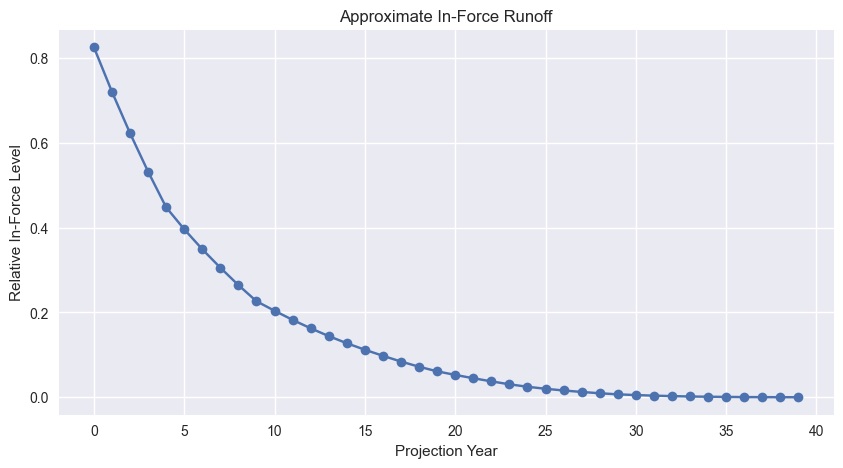

In [6]:
# Run portfolio valuation
result = portfolio.value(
    assumptions,
    return_breakdown=True
)

# Build emergence dataframe
df = profit_analysis.build_profit_dataframe(result)

# =========================
# Summary metrics
# =========================

print("=== PORTFOLIO SUMMARY ===")
print(f"PV Premiums : {result.pv_premiums:,.2f}")
print(f"PV Claims   : {result.pv_claims:,.2f}")
print(f"Net Value   : {result.net_value:,.2f}")
print()

# =========================
# Emergence preview
# =========================

print("=== EMERGENCE PREVIEW ===")

display_cols = [
    "t",
    "expected_premium",
    "expected_claim",
    "expected_lapse",
    "pv_net",
    "cum_profit"
]

display(df[display_cols].head(10))

# =========================
# Premium emergence chart
# =========================

plt.figure(figsize=(10, 5))

plt.plot(
    df["t"],
    df["expected_premium"],
    marker="o"
)

plt.title("Expected Premium Emergence")
plt.xlabel("Projection Year")
plt.ylabel("Expected Premium")

plt.grid(True)

plt.show()

# =========================
# In-force runoff chart
# =========================

plt.figure(figsize=(10, 5))

if df["expected_lapse"].sum() > 0:

    runoff = 1 - (
        df["expected_lapse"].cumsum()
        / df["expected_lapse"].sum()
    )

else:

    runoff = [1.0] * len(df)

plt.plot(
    df["t"],
    runoff,
    marker="o"
)

plt.title("Approximate In-Force Runoff")
plt.xlabel("Projection Year")
plt.ylabel("Relative In-Force Level")

plt.grid(True)

plt.show()

# Portfolio Inspection

In [7]:
len(portfolio.policies)

250

In [8]:
portfolio.policies[0]

Policy(age=60, term=12, sum_assured=25000.0, premium=291.0, gender=M, smoker_status=Smoker, product_type=Endowment, weight=63)

# Portfolio Valuation

In [9]:
portfolio_result = portfolio.value(
    assumptions,
    return_breakdown=True
)

portfolio_result

PortfolioResult(policies=250, net_value=-481686715.61)

# Portfolio DataFrame

In [10]:
portfolio_df = profit_analysis.build_profit_dataframe(
    portfolio_result
)

portfolio_df.head()

,t,age,discount_factor,lapse_rate,expected_premium,expected_claim,expected_lapse,net_cashflow,pv_premium,pv_claim,pv_net,cum_profit,cum_cashflow
0,0,60,1.000000,0.0,1.000128e+08,7.382090e+07,818.420000,2.619189e+07,1.000128e+08,7.382090e+07,2.619189e+07,2.619189e+07,2.619189e+07
1,1,61,0.959877,0.0,9.759236e+07,7.733236e+07,493.246757,2.026001e+07,9.367668e+07,7.422956e+07,1.944712e+07,4.563901e+07,4.645190e+07
2,2,62,0.918893,0.0,9.584207e+07,8.212522e+07,458.481257,1.371684e+07,8.806858e+07,7.546427e+07,1.260431e+07,5.824332e+07,6.016874e+07
3,3,63,0.881347,0.0,9.412155e+07,8.709137e+07,425.920349,7.030183e+06,8.295378e+07,7.675774e+07,6.196033e+06,6.443935e+07,6.719892e+07
4,4,64,0.845012,0.0,9.242442e+07,9.229512e+07,395.420353,1.293010e+05,7.809973e+07,7.799046e+07,1.092608e+05,6.454861e+07,6.732822e+07


# Profit Signature

In [11]:
portfolio_signature = profit_analysis.add_profit_signature(
    portfolio_df
)

portfolio_signature.head()

,t,age,discount_factor,lapse_rate,expected_premium,expected_claim,expected_lapse,net_cashflow,pv_premium,pv_claim,pv_net,cum_profit,cum_cashflow,profit_pct
0,0,60,1.000000,0.0,1.000128e+08,7.382090e+07,818.420000,2.619189e+07,1.000128e+08,7.382090e+07,2.619189e+07,2.619189e+07,2.619189e+07,-0.054375
1,1,61,0.959877,0.0,9.759236e+07,7.733236e+07,493.246757,2.026001e+07,9.367668e+07,7.422956e+07,1.944712e+07,4.563901e+07,4.645190e+07,-0.040373
2,2,62,0.918893,0.0,9.584207e+07,8.212522e+07,458.481257,1.371684e+07,8.806858e+07,7.546427e+07,1.260431e+07,5.824332e+07,6.016874e+07,-0.026167
3,3,63,0.881347,0.0,9.412155e+07,8.709137e+07,425.920349,7.030183e+06,8.295378e+07,7.675774e+07,6.196033e+06,6.443935e+07,6.719892e+07,-0.012863
4,4,64,0.845012,0.0,9.242442e+07,9.229512e+07,395.420353,1.293010e+05,7.809973e+07,7.799046e+07,1.092608e+05,6.454861e+07,6.732822e+07,-0.000227


# Summary Metrics

In [12]:
profit_analysis.summary_metrics(portfolio_df)

{'total_pv_profit': np.float64(-481686715.60508156),
 'total_cash_profit': np.float64(-1273680927.246129),
 'peak_profit_year': np.int64(0)}

# Visualisations

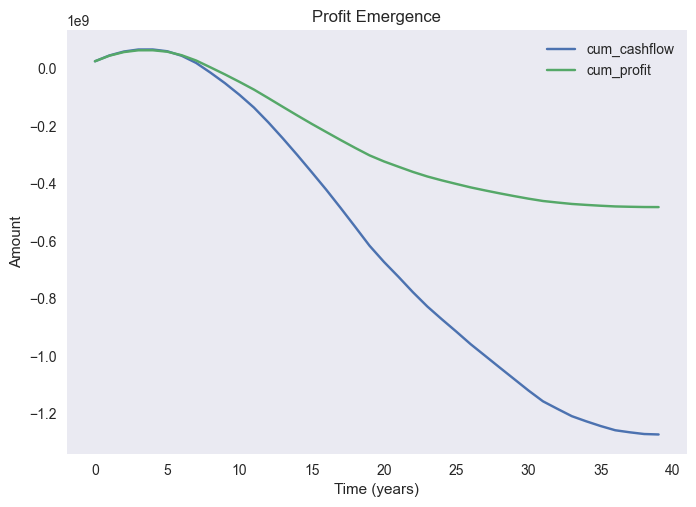

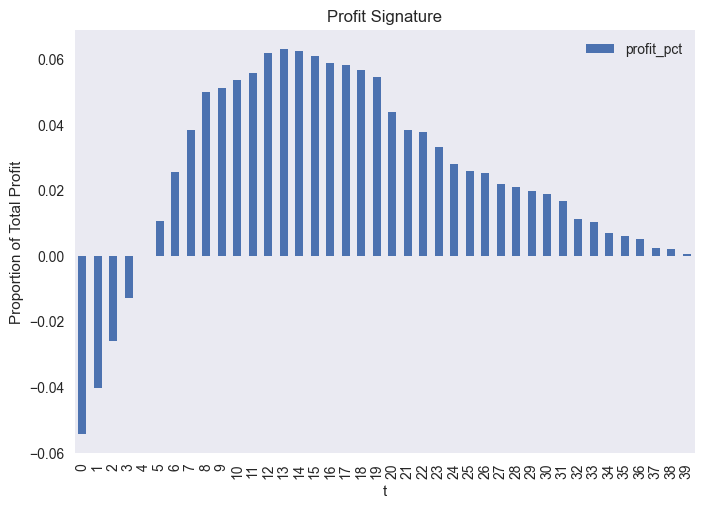

In [13]:
# Profit Emergence

portfolio_df.plot(x="t", y=["cum_cashflow", "cum_profit"])
plt.title("Profit Emergence")
plt.ylabel("Amount")
plt.xlabel("Time (years)")
plt.grid()
plt.show()


# Profit Signature

portfolio_signature.plot(x="t", y="profit_pct", kind="bar")
plt.title("Profit Signature")
plt.ylabel("Proportion of Total Profit")
plt.grid()
plt.show()